# Panel Data Introduction

Pooled ols 

fixed and random effects intro ... 



To solve these issues, it is probably easiest to go through an example. So, let's look at a data set of co2 and ...


In [1]:
%reset -f

In [2]:
from linearmodels.panel           import PooledOLS, RandomEffects, compare
from linearmodels                 import PanelOLS
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.stattools  import durbin_watson
from scipy                        import stats

import numpy.linalg      as la
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/regression_analysis/refs/heads/main/data/Co2.csv")

# transform them into index (categorical variables)

In [4]:
year = pd.Categorical(data.year)
iso_code  = pd.Categorical(data.iso_code)

# set panel id as "id" and "year" befpre checking the table

In [5]:
data = data.set_index(['iso_code', 'year'])

In [6]:
data['year'] = year
data['iso_code']  = iso_code

In [7]:
data['year'].dtypes

CategoricalDtype(categories=[1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
                  2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                  2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
, ordered=False, categories_dtype=int64)

In [8]:
data['iso_code'].dtypes

CategoricalDtype(categories=['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT',
                  'AZE', 'BDI',
                  ...
                  'UKR', 'URY', 'USA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZAF',
                  'ZMB', 'ZWE'],
, ordered=False, categories_dtype=str)

## create some helpful variables


In [9]:
data['gdp_per_cap'] = data['gdp'] / data['population']
data['ln_gdp_per_cap'] = np.log(data['gdp_per_cap'])
data['ln_co2_per_capita'] = np.log(data['co2_per_capita'])
data['ln_co2'] = np.log(data['co2'])
data['ln_Feed - in - Tariff'] = np.log(data['Feed - in - Tariff'] + 1)
data['CP'] = data['Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})']
data['ln_CP'] = np.log(data['CP']+1)
data['CP_DV'] = data['Carbon_price_DV']

In [10]:
# create lists to call on each mod
y = "ln_co2_per_capita"
X = ['CP_DV', 
     "ln_gdp_per_cap",  
     'ln_Feed - in - Tariff', 
     'ln_CP', 
     'share_global_cumulative_co2'
    ]

In [11]:
mod_ols = PooledOLS(data[y], sm.add_constant(data[X]))
pooled_res = mod_ols.fit(cov_type = 'clustered', cluster_entity = True)
print(pooled_res)    

                          PooledOLS Estimation Summary                          
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.8347
Estimator:                  PooledOLS   R-squared (Between):              0.8747
No. Observations:                4698   R-squared (Within):              -0.2916
Date:                Fri, Jun 19 2026   R-squared (Overall):              0.8347
Time:                        17:22:42   Log-likelihood                   -4929.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4739.9
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(5,4692)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             250.56
                            

# check homoskedasticity : residuals-Plot for growing variance Detection

* you can find that, as the predicted value increases, residual bandwidth changes
* hence, you need to use robust se

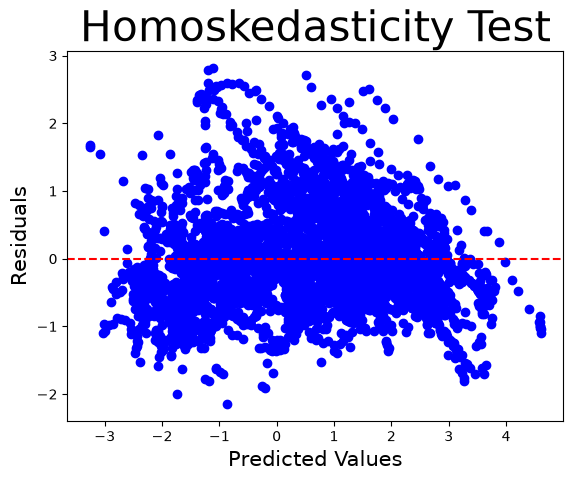

In [12]:
fittedvals_pooled_OLS = pooled_res.predict().fitted_values
residuals_pooled_OLS  = pooled_res.resids

fig, ax = plt.subplots()
ax.scatter(fittedvals_pooled_OLS, residuals_pooled_OLS, color = 'blue')
ax.axhline(0, color = 'r', ls = '--')
ax.set_xlabel('Predicted Values', fontsize = 15)
ax.set_ylabel('Residuals', fontsize = 15)
ax.set_title('Homoskedasticity Test', fontsize = 30)
plt.show()

## White-Test

In [13]:
pooled_OLS_dataset = pd.concat([data, residuals_pooled_OLS], axis=1)
white_test_results = het_white(pooled_OLS_dataset['residual'], sm.add_constant(data[X]))
labels = ['LM-Stat', 'LM p-val', 'F-Stat', 'F p-val'] 
print(dict(zip(labels, white_test_results)))

{'LM-Stat': np.float64(195.71075419173297), 'LM p-val': np.float64(7.206548289451968e-32), 'F-Stat': np.float64(11.299567951467807), 'F p-val': np.float64(1.299752224272772e-32)}


## Breusch-Pagan-Test

In [14]:
breusch_pagan_test_results = het_breuschpagan(pooled_OLS_dataset['residual'], sm.add_constant(data[X]))
print(dict(zip(labels, breusch_pagan_test_results)))

{'LM-Stat': np.float64(90.36535444658762), 'LM p-val': np.float64(5.6308101227899545e-18), 'F-Stat': np.float64(18.40398710746586), 'F p-val': np.float64(3.836663361127926e-18)}


## In simple terms, if p < 0.05, then heteroskedasticity is indicated. Both tests give very small p-values. Hence, we have heteroskedasticity

# now check autocorrelation
## Durbin-Watson-Test

In [15]:
durbin_watson_test_results = durbin_watson(pooled_OLS_dataset['residual']) 
print(durbin_watson_test_results)

0.13685382541386712


## The Durbin-Watson-Test will have one output between $0$ and $4$. The mean $(= 2)$ would indicate that there is no autocorrelation identified, $0$ to $2$ means positive autocorrelation (the nearer to zero the higher the correlation), and $2$ to $4$ means negative autocorrelation (the nearer to four the higher the correlation). In our example, the result is $0.5$, which clearly indicates strong positive autocorrelation.

# random effect

In [16]:

mod_re_rb = RandomEffects(data[y], sm.add_constant(data[X]))
re_res = mod_re_rb.fit(cov_type = 'clustered', cluster_entity = True)
print(re_res)
print(re_res.variance_decomposition)

                        RandomEffects Estimation Summary                        
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.3732
Estimator:              RandomEffects   R-squared (Between):              0.6155
No. Observations:                4698   R-squared (Within):               0.3269
Date:                Fri, Jun 19 2026   R-squared (Overall):              0.6056
Time:                        17:22:42   Log-likelihood                   -546.11
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      558.80
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(5,4692)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             24.686
                            

# Fixed Effect

In [17]:

mod_fe = PanelOLS(data[y], sm.add_constant(data[X]), entity_effects = True, time_effects = True)
fe_res = mod_fe.fit(cov_type = 'clustered', cluster_entity = True)
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.2516
Estimator:                   PanelOLS   R-squared (Between):              0.6024
No. Observations:                4698   R-squared (Within):               0.3287
Date:                Fri, Jun 19 2026   R-squared (Overall):              0.5931
Time:                        17:22:42   Log-likelihood                   -272.85
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      302.79
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(5,4503)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             22.610
                            

# hence, we need robust se, even though it does not bring too much change

---

# Hausman test : there is no Hausman test in Python, so I coded it myself.

In [18]:
b = fe_res.params
print(b)
B = re_res.params
print(B)

const                         -4.728437
CP_DV                         -0.145106
ln_gdp_per_cap                 0.594139
ln_Feed - in - Tariff          0.056500
ln_CP                         -0.052618
share_global_cumulative_co2    0.114818
Name: parameter, dtype: float64
const                         -4.901143
CP_DV                         -0.172093
ln_gdp_per_cap                 0.614595
ln_Feed - in - Tariff          0.025660
ln_CP                         -0.051147
share_global_cumulative_co2    0.104720
Name: parameter, dtype: float64


In [19]:
v_b = fe_res.cov#.drop(['const'], axis=0)
print(v_b)
v_B = re_res.cov#.drop(['const'], axis=1)
print(v_B)

                                const     CP_DV  ln_gdp_per_cap  \
const                        1.733971  0.000283       -0.196096   
CP_DV                        0.000283  0.003203       -0.000029   
ln_gdp_per_cap              -0.196096 -0.000029        0.022181   
ln_Feed - in - Tariff        0.006719  0.000068       -0.000770   
ln_CP                        0.001646 -0.000786       -0.000198   
share_global_cumulative_co2  0.017882 -0.000326       -0.002082   

                             ln_Feed - in - Tariff     ln_CP  \
const                                     0.006719  0.001646   
CP_DV                                     0.000068 -0.000786   
ln_gdp_per_cap                           -0.000770 -0.000198   
ln_Feed - in - Tariff                     0.000979  0.000079   
ln_CP                                     0.000079  0.000386   
share_global_cumulative_co2               0.000157  0.000167   

                             share_global_cumulative_co2  
const                 

In [20]:
b[np.abs(b) < 1e8].size

6

In [21]:
df = b[np.abs(b) < 1e8].size
chi2 = np.dot((b-B).T, la.inv(v_b - v_B).dot(b - B)) 
pval = stats.chi2.sf(chi2, df)


dict = {'chi-sq stat' : [chi2],
        'df' : [df],
        'p-value' : [pval]}
Hausman_df = pd.DataFrame(dict)

In [22]:
Hausman_df.round(2)

,chi-sq stat,df,p-value
0,-1.79,6,1.0


In [23]:
print(compare({"FE": fe_res,
               "RE": re_res,
               "Pooled": pooled_res
              },
             precision =  "pvalues",
              stars = True))

                                         Model Comparison                                        
                                                   FE                    RE                Pooled
-------------------------------------------------------------------------------------------------
Dep. Variable                       ln_co2_per_capita     ln_co2_per_capita     ln_co2_per_capita
Estimator                                    PanelOLS         RandomEffects             PooledOLS
No. Observations                                 4698                  4698                  4698
Cov. Est.                                   Clustered             Clustered             Clustered
R-squared                                      0.2516                0.3732                0.8347
R-Squared (Within)                             0.3287                0.3269               -0.2916
R-Squared (Between)                            0.6024                0.6155                0.8747
R-Squared (Overall) 